# Tutoriel: creer un dataset Aube

Ce notebook documente une creation de dataset a partir de plusieurs cas Telemac du repertoire `Aube/`.

Le but est documentaire: les chemins ci-dessous sont fictifs, et l'execution est desactivee par defaut.
Pour lancer une vraie generation, il suffit de remplacer `AUBE_ROOT` et `OUTPUT_DIR`, puis de passer `RUN_CREATION = True`.

## Hypothese de structure

On suppose une arborescence du type:

```text
/work/m24046/m24046mrcr/Aube
├── 07_EA04_T3_V12_Q100_v1/
├── ...
└── ...
```

Dans chaque dossier de cas, le notebook cherche automatiquement:
- un fichier `*.slf` pour le maillage,
- un fichier `*.res` pour les resultats,
- un fichier `*.cli` ou `*.conlim` pour les conditions aux limites.

In [1]:
from pathlib import Path
from pprint import pprint
import sys

repo_root = Path.cwd().resolve()
if not (repo_root / "python" / "create_dgl_dataset.py").exists():
    candidate = repo_root.parent
    if (candidate / "python" / "create_dgl_dataset.py").exists():
        repo_root = candidate
    else:
        raise RuntimeError("Impossible to locate the repository root from the current notebook directory.")

if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from python.create_dgl_dataset import create_dgl_dataset_chunked

In [2]:
AUBE_ROOT = Path("/work/m24046/m24046mrcr/Aube")
CASE_DIRS = [
    AUBE_ROOT / "07_EA04_T3_V12_Q100_v1"
]

OUTPUT_DIR = Path("/work/m24046/m24046mrcr/Aube/datasets/aube_chunked")
DATASET_NAME = "Aube_demo"
CHUNK_SIZE = 80
DT_VALUE = 1

print({
    "AUBE_ROOT": str(AUBE_ROOT),
    "OUTPUT_DIR": str(OUTPUT_DIR),
    "DATASET_NAME": DATASET_NAME,
    "CHUNK_SIZE": CHUNK_SIZE,
    "DT_VALUE": DT_VALUE,
    "RUN_CREATION": RUN_CREATION,
})

NameError: name 'RUN_CREATION' is not defined

In [ ]:
def find_single_file(case_dir: Path, patterns):
    matches = []
    for pattern in patterns:
        matches.extend(sorted(case_dir.glob(pattern)))

    unique_matches = []
    seen = set()
    for match in matches:
        key = str(match)
        if key not in seen:
            seen.add(key)
            unique_matches.append(match)

    if not unique_matches:
        raise FileNotFoundError(f"No file found in {case_dir} for patterns {patterns}")
    if len(unique_matches) > 1:
        names = ", ".join(path.name for path in unique_matches)
        raise RuntimeError(f"Multiple files found in {case_dir}: {names}")

    return unique_matches[0]


def resolve_case(case_dir: Path):
    result = {
        "case_dir": case_dir,
        "mesh_file": None,
        "res_file": None,
        "bnd_file": None,
        "ready": False,
        "error": None,
    }

    if not case_dir.exists():
        result["error"] = "Case directory does not exist yet. This is expected while the paths are still fictive."
        return result

    try:
        result["mesh_file"] = find_single_file(case_dir, ["*.slf"])
        result["res_file"] = find_single_file(case_dir, ["*.res"])
        result["bnd_file"] = find_single_file(case_dir, ["*.cli", "*.conlim"])
        result["ready"] = True
    except Exception as exc:
        result["error"] = str(exc)

    return result


case_configs = [resolve_case(case_dir) for case_dir in CASE_DIRS]
pprint(case_configs)

In [ ]:
def build_dataset_args(case_configs):
    ready_cases = [case for case in case_configs if case["ready"]]
    if len(ready_cases) != len(case_configs):
        missing_cases = [str(case["case_dir"]) for case in case_configs if not case["ready"]]
        raise RuntimeError(
            "Some case folders are not ready yet. Update AUBE_ROOT or the input files first: "
            + ", ".join(missing_cases)
        )

    return {
        "mesh_list": [str(case["mesh_file"]) for case in ready_cases],
        "res_list": [str(case["res_file"]) for case in ready_cases],
        "cli_list": [str(case["bnd_file"]) for case in ready_cases],
        "dt_list": [DT_VALUE] * len(ready_cases),
        "data_folder": str(OUTPUT_DIR),
        "dataset_name": DATASET_NAME,
        "chunk_size": CHUNK_SIZE,
    }


dataset_args = None
try:
    dataset_args = build_dataset_args(case_configs)
    pprint(dataset_args)
except Exception as exc:
    print(exc)

In [14]:
for case in case_configs:
    if not case["ready"]:
        raise RuntimeError(f"Case not ready: {case['case_dir']} -> {case['error']}")

    dataset_name = case["res_file"].stem

    create_dgl_dataset_chunked(
        mesh_list=[str(case["mesh_file"])],
        res_list=[str(case["res_file"])],
        cli_list=[str(case["bnd_file"])],
        dt_list=[DT_VALUE],
        data_folder=str(OUTPUT_DIR),
        dataset_name=dataset_name,
        chunk_size=CHUNK_SIZE,
    )

## Fichiers generes

Si la creation est lancee, le dossier `OUTPUT_DIR` contient ensuite:
- `T3_V12_EA04_Q100_v1_base.bin`: le graphe de base DGL du premier cas,
- `T3_V12_EA04_Q100_v1_0_0.pkl`: chunks du premier cas,

Si tous les cas sont les mêmes les graphes .bin sont interchangeables.

In [17]:
!ls /work/m24046/m24046mrcr/Aube/datasets/aube_chunked/

T3_V12_EA04_Q100_v1_0_0-70.pkl	T3_V12_EA04_Q100_v1_base.bin


### Visualisation

In [18]:
from pathlib import Path
import sys
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import dgl

plt.rcParams["figure.dpi"] = 120

candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent]
repo_root = next(p for p in candidates if (p / "python" / "create_dgl_dataset.py").exists())
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from python.python_code.data_manip.extraction.telemac_file import TelemacFile


In [21]:
CASE_DIR = Path("/work/m24046/m24046mrcr/Aube/07_EA04_T3_V12_Q100_v1")
DATASET_DIR = Path("/work/m24046/m24046mrcr/Aube/datasets/aube_chunked")

MESH_PATH = CASE_DIR / "T3_V12_v2_EA04.slf"
RES_PATH = CASE_DIR / "T3_V12_EA04_Q100_v1.res"
BND_PATH = CASE_DIR / "cas.conlim"

BASE_PATH = DATASET_DIR / "T3_V12_EA04_Q100_v1_base.bin"
PKL_PATH = DATASET_DIR / "T3_V12_EA04_Q100_v1_0_0-70.pkl"

sample_idx = 10


In [22]:
mesh = TelemacFile(str(MESH_PATH))
res = TelemacFile(str(RES_PATH), bnd_file=str(BND_PATH))
base_graph = dgl.load_graphs(str(BASE_PATH))[0][0]

with open(PKL_PATH, "rb") as f:
    dynamic_data = pickle.load(f)

tri = mtri.Triangulation(mesh.tri.x, mesh.tri.y, mesh.tri.triangles)

static = base_graph.ndata["static"].cpu().numpy()
node_type = static[:, :4]
strickler = static[:, 4]
z = static[:, 5]

def unpack(sample):
    if isinstance(sample, dict):
        return sample["x"], sample["y"], sample.get("ts", None)
    if len(sample) == 2:
        x, y = sample
        return x, y, None
    if len(sample) == 3:
        x, y, ts = sample
        return x, y, int(ts)
    raise ValueError(f"Unsupported sample format: {type(sample)}")

x, y, ts = unpack(dynamic_data[sample_idx])

print("n_nodes   =", len(mesh.tri.x))
print("n_edges   =", base_graph.num_edges())
print("n_samples =", len(dynamic_data))
print("static shape =", static.shape)
print("x shape =", x.shape, "| y shape =", y.shape, "| ts =", ts)

assert len(mesh.tri.x) == static.shape[0] == x.shape[0] == y.shape[0]


n_nodes   = 852814
n_edges   = 5103692
n_samples = 70
static shape = (852814, 6)
x shape = (852814, 3) | y shape = (852814, 3) | ts = 10


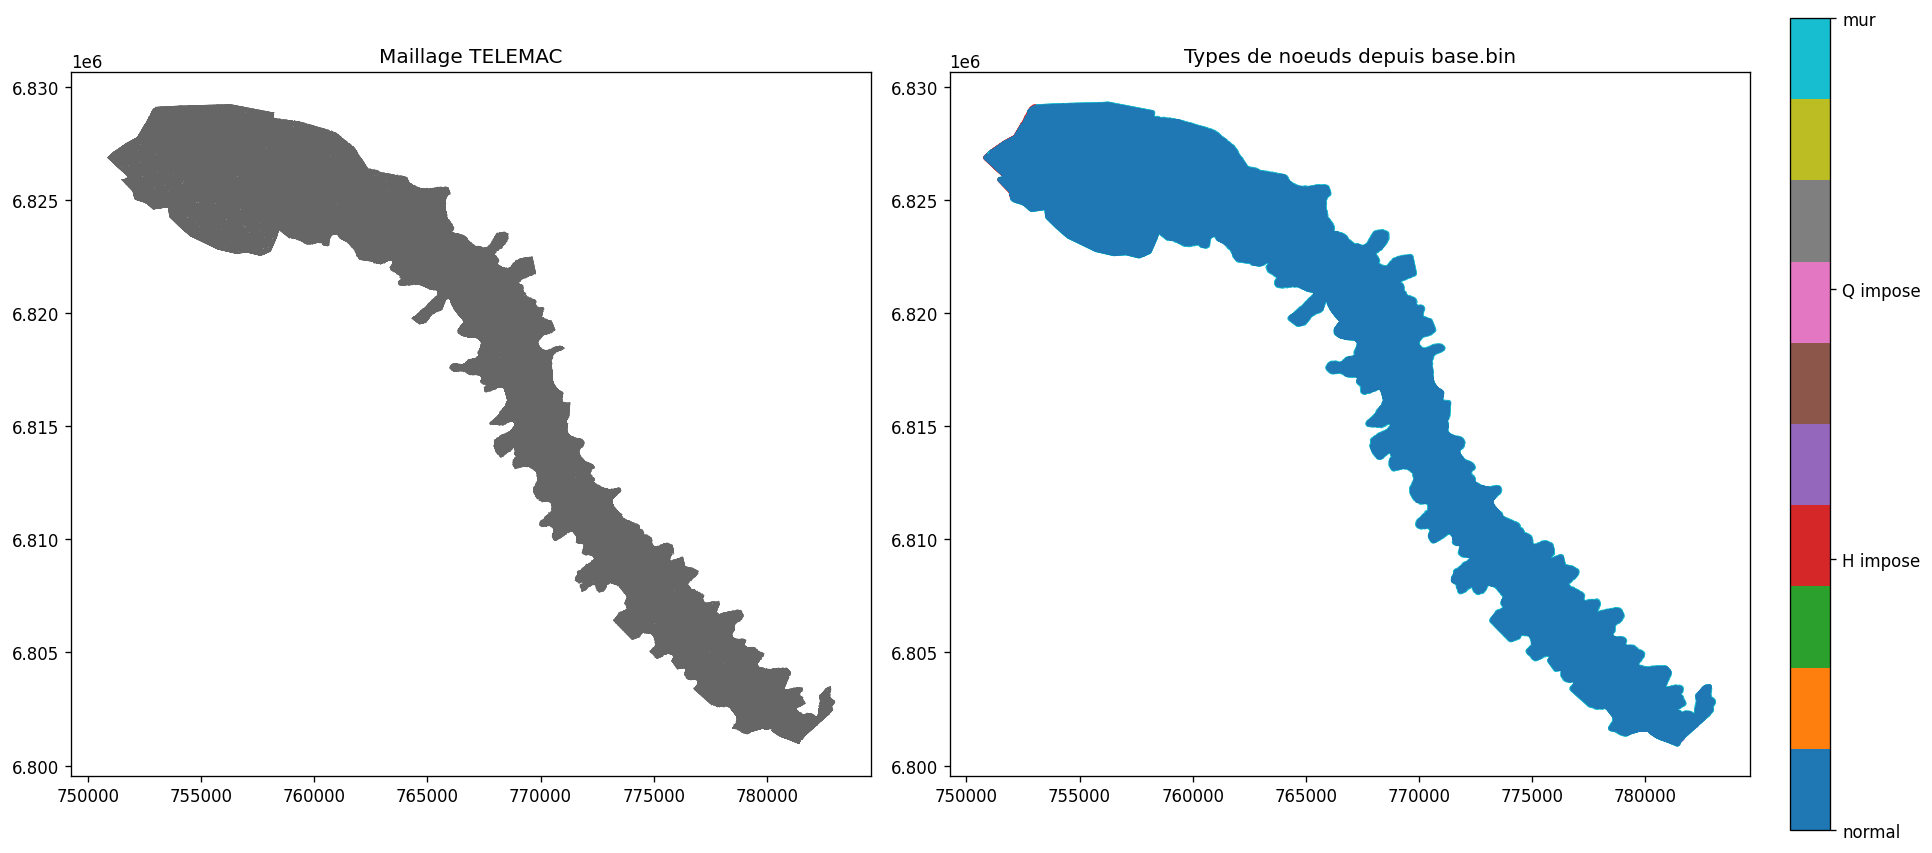

In [23]:
labels = np.argmax(node_type, axis=1)
label_names = {0: "normal", 1: "H impose", 2: "Q impose", 3: "mur"}

fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

axes[0].triplot(tri, lw=0.2, color="0.4")
axes[0].set_title("Maillage TELEMAC")
axes[0].set_aspect("equal")

sc = axes[1].scatter(mesh.tri.x, mesh.tri.y, c=labels, s=5, cmap="tab10")
axes[1].set_title("Types de noeuds depuis base.bin")
axes[1].set_aspect("equal")
cbar = plt.colorbar(sc, ax=axes[1], ticks=[0, 1, 2, 3])
cbar.ax.set_yticklabels([label_names[i] for i in [0, 1, 2, 3]])

plt.show()

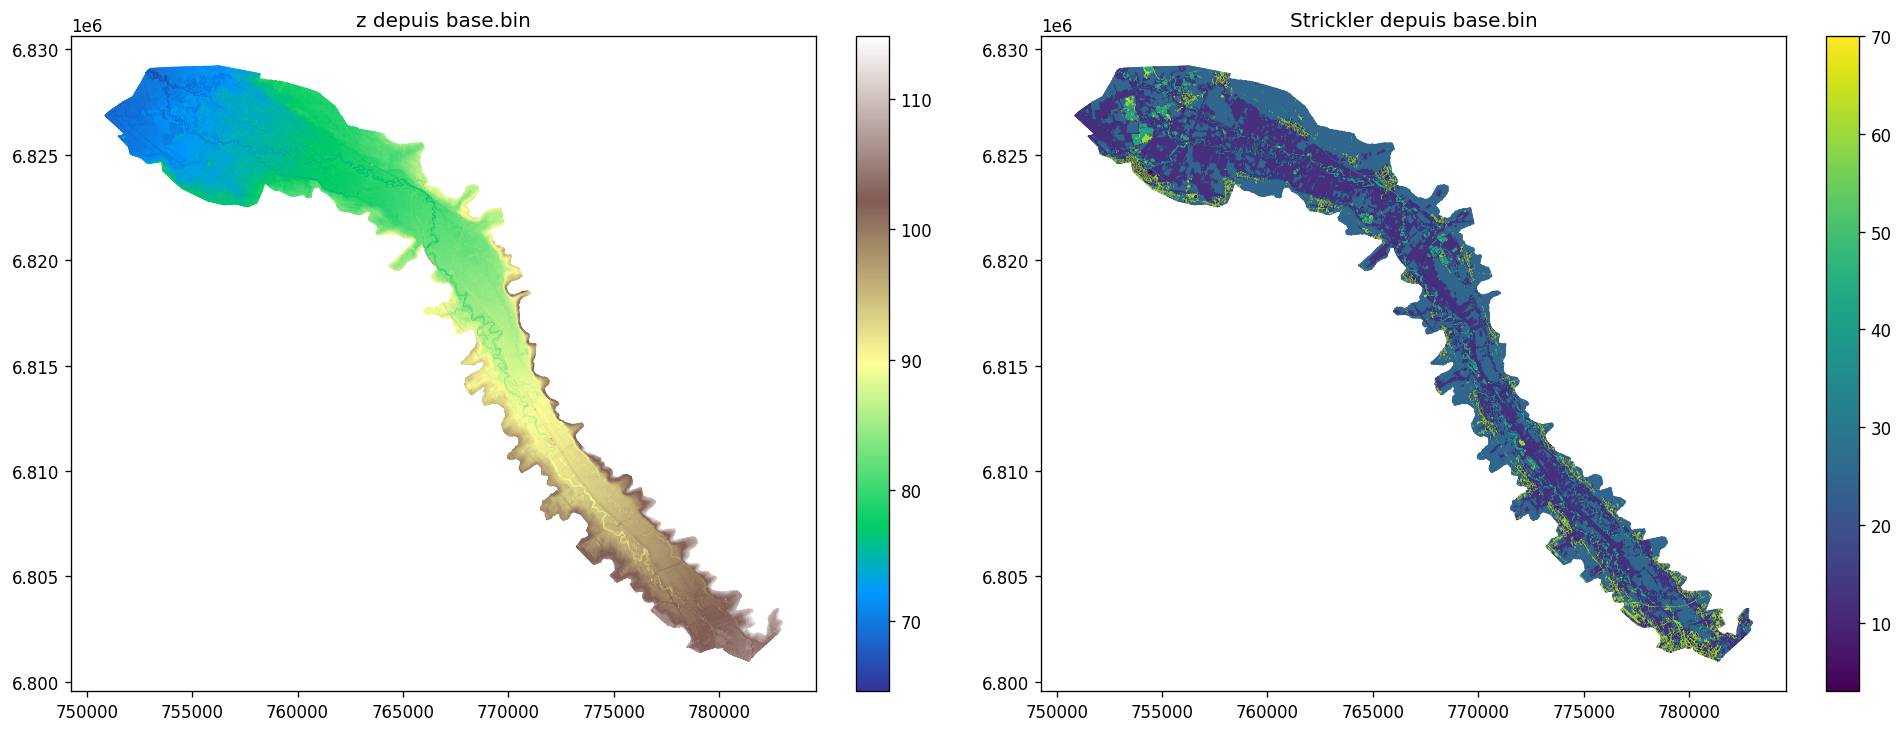

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

im0 = axes[0].tripcolor(tri, z, shading="gouraud", cmap="terrain")
axes[0].set_title("z depuis base.bin")
axes[0].set_aspect("equal")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].tripcolor(tri, strickler, shading="gouraud", cmap="viridis")
axes[1].set_title("Strickler depuis base.bin")
axes[1].set_aspect("equal")
plt.colorbar(im1, ax=axes[1])

plt.show()


,Graph,Unique edges,Min [m],P05 [m],P25 [m],Median [m],P75 [m],P95 [m],Max [m],Max / Min
0,Reference Telemac mesh,1232165,0.75,2.70,4.89,6.97,21.06,52.59,82.97,110.59
1,Aube Telemac mesh,2551846,0.20,3.75,6.07,9.97,13.84,33.68,77.73,386.29
2,Projected x8 mesh,48492,5.90,19.01,35.49,49.90,92.87,247.50,630.16,106.84
3,Projected x8 +multimesh,65279,5.90,21.50,39.49,64.15,135.10,353.38,2521.22,427.48
4,Aube Telemac coarse,5318,2.69,52.54,142.41,178.04,219.74,276.18,369.76,137.57


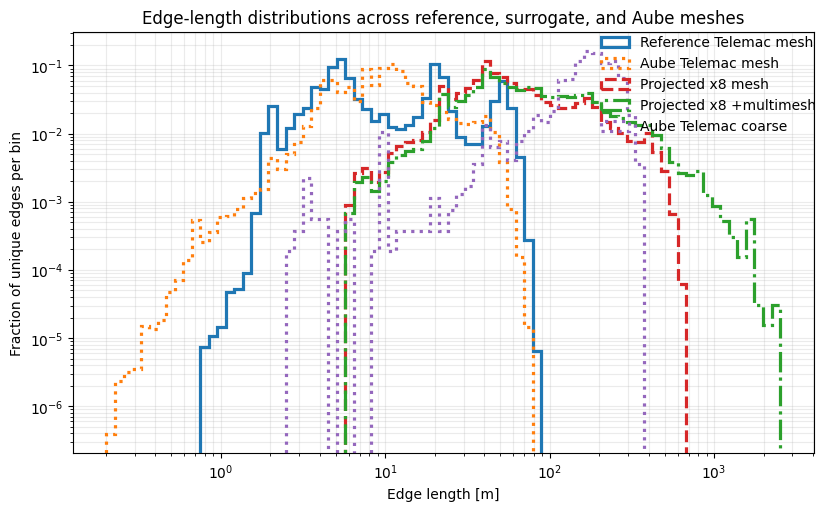

In [11]:
# Edge-length distributions including the new Aube mesh

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dgl
from python.python_code.data_manip.extraction.telemac_file import TelemacFile
DATA_DIRS = {
    "multimesh": "/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Multimesh_8_32.bin",
    "normal": '/work/m24046/m24046mrcr/dataset_x8_avec_ts/shortx8/Mesh8_base.bin',
}
# Existing reference mesh
HIGH_RES_MESH_PATH = "/work/m24046/m24046mrcr/results_data_30min/maillage_3.slf"

# New Aube case
AUBE_MESH_PATH = "/work/m24046/m24046mrcr/Aube/07_EA04_T3_V12_Q100_v1/T3_V12_v2_EA04.slf"

AUBE_MESH_COARSE_PATH = '/work/m24046/m24046mrcr/Aube/automatic_coarse_mesh_T2.bin'


# Existing surrogate graphs
GRAPH_PATHS = {
    "Projected x8 mesh": DATA_DIRS["normal"],
    "Projected x8 +multimesh": DATA_DIRS["multimesh"],
    "Aube Telemac coarse" : AUBE_MESH_COARSE_PATH
}

# Telemac meshes to compare directly
TELEMAC_MESH_PATHS = {
    "Reference Telemac mesh": HIGH_RES_MESH_PATH,
    "Aube Telemac mesh": AUBE_MESH_PATH,
    
}

SAVE_FIG = None  # e.g. "edge_length_distributions_with_aube.png"


def unique_edge_lengths_from_telemac(mesh_path):
    mesh = TelemacFile(mesh_path)
    tri = mesh.tri.triangles

    edges = np.vstack([
        np.sort(tri[:, [0, 1]], axis=1),
        np.sort(tri[:, [1, 2]], axis=1),
        np.sort(tri[:, [2, 0]], axis=1),
    ])
    edges = np.unique(edges, axis=0)

    x = np.asarray(mesh.tri.x)
    y = np.asarray(mesh.tri.y)
    dx = x[edges[:, 0]] - x[edges[:, 1]]
    dy = y[edges[:, 0]] - y[edges[:, 1]]
    return np.sqrt(dx**2 + dy**2)


def unique_edge_lengths_from_dgl(graph_path):
    graphs, _ = dgl.load_graphs(graph_path)
    g = graphs[0]

    src, dst = g.edges()
    src = src.cpu().numpy()
    dst = dst.cpu().numpy()

    mask = src != dst
    undirected = np.sort(np.column_stack([src[mask], dst[mask]]), axis=1)
    _, first_idx = np.unique(undirected, axis=0, return_index=True)

    edge_lengths = g.edata["x"][:, 2].cpu().numpy()[mask]
    return edge_lengths[np.sort(first_idx)]


def summarize_lengths(name, lengths):
    q05, q25, q50, q75, q95 = np.percentile(lengths, [5, 25, 50, 75, 95])
    return {
        "Graph": name,
        "Unique edges": len(lengths),
        "Min [m]": lengths.min(),
        "P05 [m]": q05,
        "P25 [m]": q25,
        "Median [m]": q50,
        "P75 [m]": q75,
        "P95 [m]": q95,
        "Max [m]": lengths.max(),
        "Max / Min": lengths.max() / lengths.min(),
    }


for p in list(TELEMAC_MESH_PATHS.values()) + list(GRAPH_PATHS.values()):
    assert Path(p).exists(), f"Missing file: {p}"

length_sets = {
    **{name: unique_edge_lengths_from_telemac(path) for name, path in TELEMAC_MESH_PATHS.items()},
    **{name: unique_edge_lengths_from_dgl(path) for name, path in GRAPH_PATHS.items()},
}

summary_df = pd.DataFrame(
    [summarize_lengths(name, lengths) for name, lengths in length_sets.items()]
)
display(summary_df.round(2))

plot_order = [
    "Reference Telemac mesh",
    "Aube Telemac mesh",
    "Projected x8 mesh",
    "Projected x8 +multimesh",
    "Aube Telemac coarse"
]

colors = {
    "Reference Telemac mesh": "#1f77b4",
    "Aube Telemac mesh": "#ff7f0e",
    "Projected x8 mesh": "#d62728",
    "Projected x8 +multimesh": "#2ca02c",
    "Aube DGL graph": "#9467bd",
    "Aube Telemac coarse": "#9467bd",
}

linestyles = {
    "Reference Telemac mesh": "-",
    "Aube Telemac mesh": ":",
    "Projected x8 mesh": "--",
    "Projected x8 +multimesh": "-.",
    "Aube DGL graph": (0, (3, 1, 1, 1)),
    "Aube Telemac coarse": ":",
}

all_lengths = np.concatenate([length_sets[name] for name in plot_order])
bins = np.geomspace(all_lengths.min(), all_lengths.max(), 80)

fig, ax = plt.subplots(figsize=(8.2, 5.0), constrained_layout=True)

for name in plot_order:
    lengths = length_sets[name]
    weights = np.full(lengths.shape, 1.0 / len(lengths), dtype=float)

    ax.hist(
        lengths,
        bins=bins,
        weights=weights,
        histtype="step",
        linewidth=2.3,
        color=colors[name],
        linestyle=linestyles[name],
        label=name,
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Edge length [m]")
ax.set_ylabel("Fraction of unique edges per bin")
ax.set_title("Edge-length distributions across reference, surrogate, and Aube meshes")
ax.grid(True, which="both", alpha=0.25)
ax.legend(frameon=False, loc="upper right", bbox_to_anchor=(1.02, 1.02))

if SAVE_FIG is not None:
    fig.savefig(SAVE_FIG, dpi=300, bbox_inches="tight")

plt.show()
